# 🏥 Diabetes Risk Prediction - Early Detection System
## Notebook 1: Data Exploration & Analysis

**Author:** Cephas Adams Kumah  
**Dataset:** CDC Diabetes Health Indicators - BRFSS 2015 (Kaggle)  
**Records:** 253,680 raw records · 229,474 after deduplication  
**Objective:** Explore the CDC behavioural risk factor dataset to 
understand the distribution of diabetes indicators, identify key 
risk factors, and inform feature selection for the prediction model.

---
| Step | Description |
|---|---|
| 1. Setup | Load libraries and configure chart styling |
| 2. Load Data | Import dataset, inspect shape and columns |
| 3. Data Quality | Check missing values, duplicates, class balance |
| 4. Remove Duplicates | Drop 24,206 duplicate rows |
| 5. Target Analysis | Understand diabetes prevalence (84.7% / 15.3%) |
| 6. Risk Factor Analysis | Explore BMI and age distribution by diabetes status |
| 7. Lifestyle Factors | Analyse physical activity, smoking, alcohol, diet |
| 8. Healthcare Access | Explore income and education vs diabetes rate |
| 9. Correlation Analysis | Identify strongest predictors across all 21 features |

## 1. Setup

In [2]:



# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure chart styling
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})



print("=" * 40)
print("  Libraries loaded successfully")
print("=" * 40)

  Libraries loaded successfully


## 2. Load Data
The CDC BRFSS 2015 Diabetes Health Indicators dataset contains 
survey responses from 253,680 U.S. adults, reduced to 229,474 
unique records after removing duplicates. The dataset includes 
diabetes status, physical health indicators, lifestyle behaviours, 
healthcare access variables, and socioeconomic factors.



In [3]:
# load dataset
df = pd.read_csv('../data/diabetes_binary_health_indicators_BRFSS2015.csv')

print("=" * 40)
print(f" Row:s {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("=" * 40)

print(f"\nColumn names:")
print(df.columns.tolist())

print(f"\nData types:")
print(df.dtypes)

 Row:s 253,680
Columns: 22

Column names:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Data types:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               f

## 3. Data Quality

In this section, we assess the overall quality and structure of the dataset before analysis. This includes checking for missing values, duplicate records, data types, and the class balance of the target variable.

The CDC BRFSS 2015 Diabetes Health Indicators dataset is already pre-cleaned, so we expect minimal missing data or formatting issues. However, these checks are still important to confirm that the dataset is ready for exploratory analysis and modeling.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nDuplicated rows: {df.duplicated().sum():,}")

print(f"\nBasic statistics:")
print(df.describe())

Missing values per column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Duplicated rows: 24,206

Basic statistics:
       Diabetes_binary         HighBP       HighChol      CholCheck            BMI         Smoker         Stroke  HeartDiseaseorAttack   PhysActivity         Fruits        Veggies  HvyAlcoholConsump  AnyHealthcare    NoDocbcCost        GenHlth       MentHlth       PhysHlth       DiffWalk            Sex            Age      Education         In

## 4. Remove Duplicates

During the data quality check, **24,206 duplicate rows** were identified, representing approximately **9.5% of the dataset**.

These duplicate records contain identical combinations of survey responses. Keeping them could bias the model by over-representing certain health and risk profiles. To reduce this risk and improve model reliability, duplicate rows are removed before further analysis and modeling.

In [5]:
# Remove duplicate rows
df_clean = df.drop_duplicates().reset_index(drop=True)

print("=" * 40)
print(f"  Rows before: {len(df):,}")
print(f"  Rows removed: {df.duplicated().sum():,}")
print(f"  Rows after:  {len(df_clean):,}")
print("=" * 40)

# Replace df with cleaned version
df = df_clean

  Rows before: 253,680
  Rows removed: 24,206
  Rows after:  229,474


## 5. Target Variable Analysis

The target variable `Diabetes_binary` indicates whether a respondent has been diagnosed with diabetes.

- `0` = No diabetes  
- `1` = Diabetes  

In this section, we examine the distribution of the target variable to understand the class balance in the dataset. This is important because imbalanced classes can affect model performance and may require special handling during model training, such as stratified splitting, resampling, or adjusted evaluation metrics.

Class Distribution:
No Diabetes: 194,377 (84.7%)
Diabetes: 35,097 (15.3%)


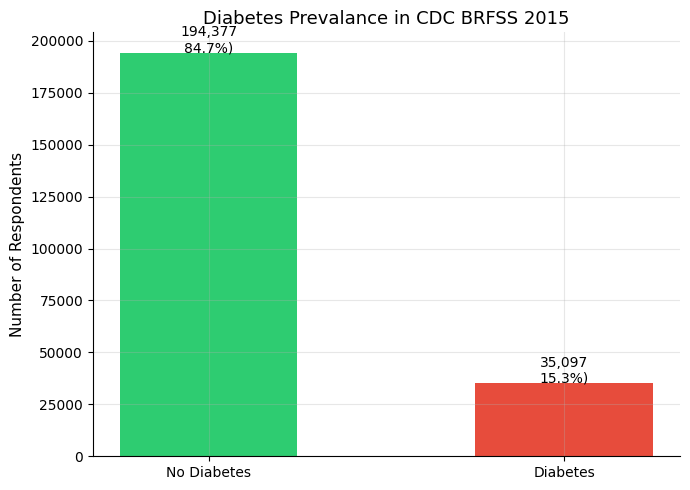

In [6]:
# Class distribution
target_counts = df['Diabetes_binary'].value_counts()
target_pct = df['Diabetes_binary'].value_counts(normalize=True)*100

print("Class Distribution:")
print(f"No Diabetes: {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"Diabetes: {target_counts[1]:,} ({target_pct[1]:.1f}%)")

#plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['No Diabetes', 'Diabetes'], 
       target_counts.values,
       color=['#2ecc71', '#e74c3c'], width=0.5)
ax.set_title('Diabetes Prevalance in CDC BRFSS 2015')
ax.set_ylabel('Number of Respondents')

for i,  v in  enumerate(target_counts.values):
    ax.text(i, v + 200, 
            f'{v:,}\n{target_pct.values[i]:.1f}%)',
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()          


## 6. Risk Factor Analysis

To better understand key predictors of diabetes, we explore the distribution of **BMI** and **age** by diabetes status. BMI is a continuous health indicator linked to obesity-related risk, while age is a known non-modifiable risk factor for diabetes. These visualisations help reveal whether respondents with diabetes tend to have higher BMI values and belong to older age categories.

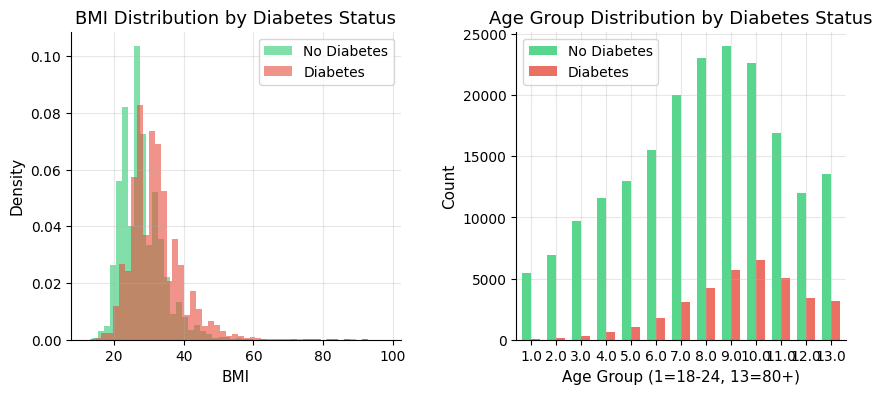

In [10]:
# BMI distribution by diabetes status
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.35)
# BMI histogram
for label, group in df.groupby('Diabetes_binary'):
    name = 'Diabetes' if label ==1 else 'No Diabetes'
    color = '#e74c3c' if label == 1 else '#2ecc71'
    axes[0].hist(
        group['BMI'],
        bins=50,
        alpha=0.6,
        label=name,
        color=color,
        density=True
    )
axes[0].set_title('BMI Distribution by Diabetes Status')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Density')
axes[0].legend()

# Age distribution by diabetes status
age_diabetes = df.groupby(['Age', 'Diabetes_binary']).size().unstack().sort_index()

age_diabetes.plot(
    kind='bar',
    ax=axes[1],
    color=['#2ecc71', '#e74c3c'],
    alpha=0.8,
    width=0.7
)
axes[1].set_title('Age Group Distribution by Diabetes Status')
axes[1].set_xlabel('Age Group (1=18-24, 13=80+)')
axes[1].set_ylabel('Count')
axes[1].legend(['No Diabetes', 'Diabetes'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout
plt.savefig('../visuals/bmi_age_analysis.png', dpi=150, bbox_inches='tight')

In [7]:
# Print key findings
avg_bmi_diabetic = df[df['Diabetes_binary']==1]['BMI'].mean()
avg_bmi_healthy = df[df['Diabetes_binary']==0]['BMI'].mean()

print("=" * 45)
print("  BMI & AGE FINDINGS")
print("=" * 45)
print(f"  Avg BMI — No Diabetes: {avg_bmi_healthy:.1f}")
print(f"  Avg BMI — Diabetes:    {avg_bmi_diabetic:.1f}")
print(f"  BMI difference:        +{avg_bmi_diabetic - avg_bmi_healthy:.1f} points")
print("-" * 45)
print("  Peak diabetes age group: 9-11 (60-74 years)")
print("  Near-zero diabetes under age group 5 (< 44)")
print("=" * 45)

  BMI & AGE FINDINGS
  Avg BMI — No Diabetes: 28.1
  Avg BMI — Diabetes:    32.0
  BMI difference:        +3.9 points
---------------------------------------------
  Peak diabetes age group: 9-11 (60-74 years)
  Near-zero diabetes under age group 5 (< 44)


### Key Findings

**BMI:**
- Respondents with diabetes have a higher average BMI (**32.0**) compared with respondents without diabetes (**28.1**), a difference of **+3.9 BMI points**.
- The BMI distribution for respondents with diabetes is shifted toward higher values, suggesting that elevated BMI is strongly associated with diabetes status.
- Higher BMI values, including obesity-range BMI levels, appear more common among respondents with diabetes.
- BMI will be prioritised as a key feature in the prediction model.

**Age:**
- Diabetes rates are relatively low among younger age groups, especially respondents aged **18–44 years**.
- Diabetes risk increases noticeably from middle age onward, particularly from age group 6, which represents respondents aged **45–49 years**.
- Age groups 9–11, representing respondents aged **60–74 years**, show a higher diabetes burden in this dataset.
- Although age is non-modifiable, it is important for clinical risk stratification and diabetes risk prediction.
    

## 7. Lifestyle Factors

In this section, we examine five behavioural risk factors that respondents can potentially modify through lifestyle changes.

| Feature | Description |
|---|---|
| **PhysActivity** | Physical activity in the past 30 days; `1 = Yes`, `0 = No` |
| **Smoker** | Smoked at least 100 cigarettes in their lifetime; `1 = Yes`, `0 = No` |
| **HvyAlcoholConsump** | Heavy alcohol consumption; `1 = Yes`, `0 = No` |
| **Fruits** | Consumes fruit one or more times per day; `1 = Yes`, `0 = No` |
| **Veggies** | Consumes vegetables one or more times per day; `1 = Yes`, `0 = No` |

> These lifestyle factors are clinically important because they are actionable.  
> If a respondent is flagged as high-risk by the model, these variables can help guide practical lifestyle intervention recommendations such as increased physical activity, improved diet, smoking cessation, and reduced alcohol intake.

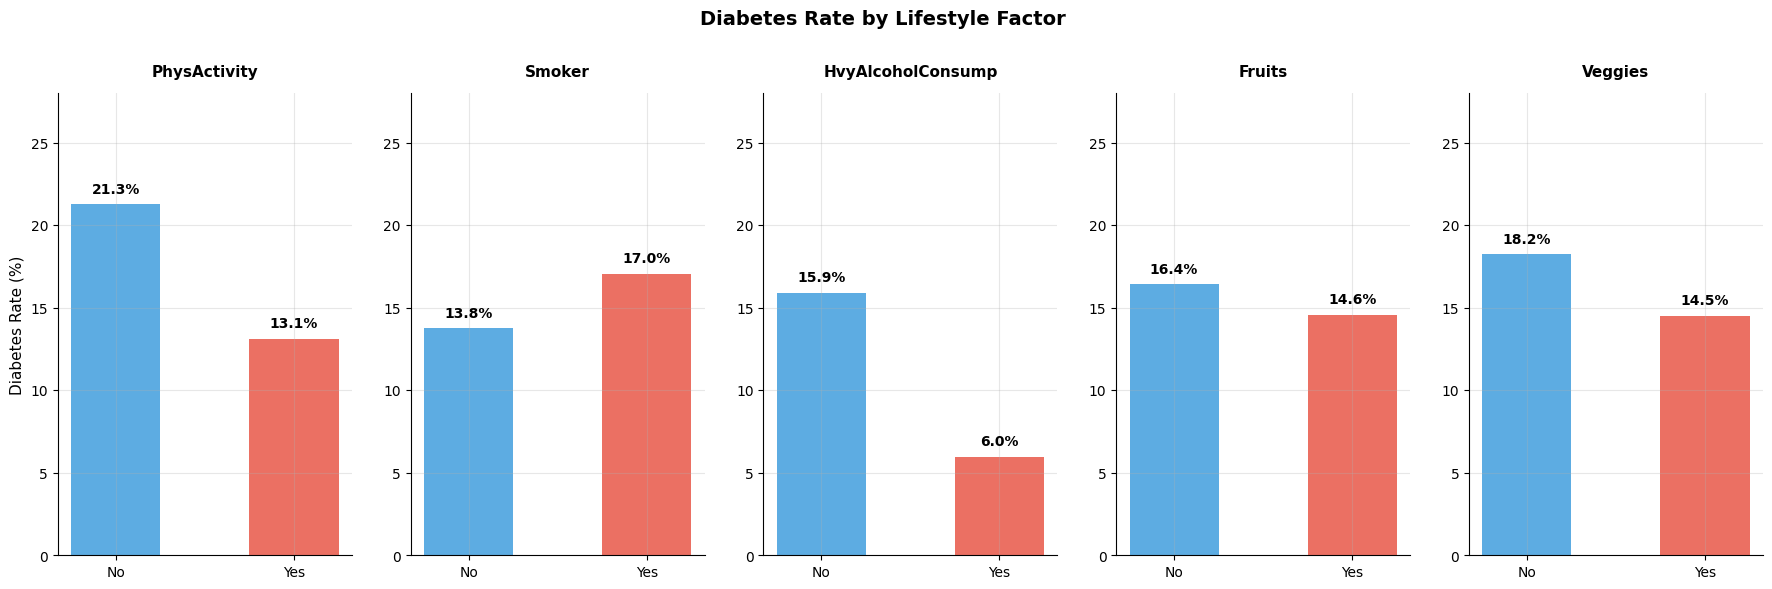

In [8]:
lifestyle_features = [
                'PhysActivity', 
                'Smoker',
                'HvyAlcoholConsump', 
               'Fruits', 
               'Veggies'
]

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, feature in enumerate(lifestyle_features):
    rate = df.groupby(feature)['Diabetes_binary'].mean() * 100
    bars = axes[i].bar(['No', 'Yes'], rate.values,
                       color=['#3498db', '#e74c3c'],
                       alpha=0.8, width=0.5)
    axes[i].set_title(feature, fontsize=11, fontweight='bold', pad=12)
    axes[i].set_ylim(0, 28)
    axes[i].set_ylabel('Diabetes Rate (%)' if i == 0 else '')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     val + 0.5,
                     f'{val:.1f}%',
                     ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

fig.suptitle('Diabetes Rate by Lifestyle Factor',
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig('../visuals/lifestyle_factors.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Lifestyle Factor Findings

**Physical Activity:**
- Respondents who reported no physical activity had a higher diabetes rate (**21.3%**) compared with those who were physically active (**13.1%**).
- This suggests that physical activity is associated with lower diabetes risk in the dataset.

**Smoking:**
- Respondents with a smoking history had a higher diabetes rate (**17.0%**) compared with non-smokers (**13.8%**).
- Smoking may contribute additional health risk and could be useful as a supporting predictor in the model.

**Heavy Alcohol Consumption:**
- Respondents classified as heavy alcohol consumers had a lower diabetes rate (**6.0%**) compared with non-heavy alcohol consumers (**15.9%**).
- This result should be interpreted carefully because it may reflect confounding factors, smaller subgroup size, or changes in behaviour after diagnosis rather than a direct protective effect.

**Fruit and Vegetable Consumption:**
- Respondents who consumed fruits daily had a slightly lower diabetes rate (**14.6%**) compared with those who did not (**16.4%**).
- Respondents who consumed vegetables daily also had a lower diabetes rate (**14.5%**) compared with those who did not (**18.2%**).
- These differences suggest that healthier dietary habits may be associated with lower diabetes risk.

**Overall Insight:**
- Lifestyle factors show meaningful differences in diabetes rates, especially physical activity and vegetable consumption.
- However, these relationships should be treated as associations, not proof of causation.
- These features will be retained for modeling because they provide actionable information that can support risk interpretation and lifestyle intervention recommendations.

### Income and Education Analysis

This analysis examines how diabetes rates vary across income and education levels. Both variables are socioeconomic indicators that may influence access to preventive care, health literacy, lifestyle options, and disease management.

The charts below show the percentage of respondents with diabetes within each income and education category.

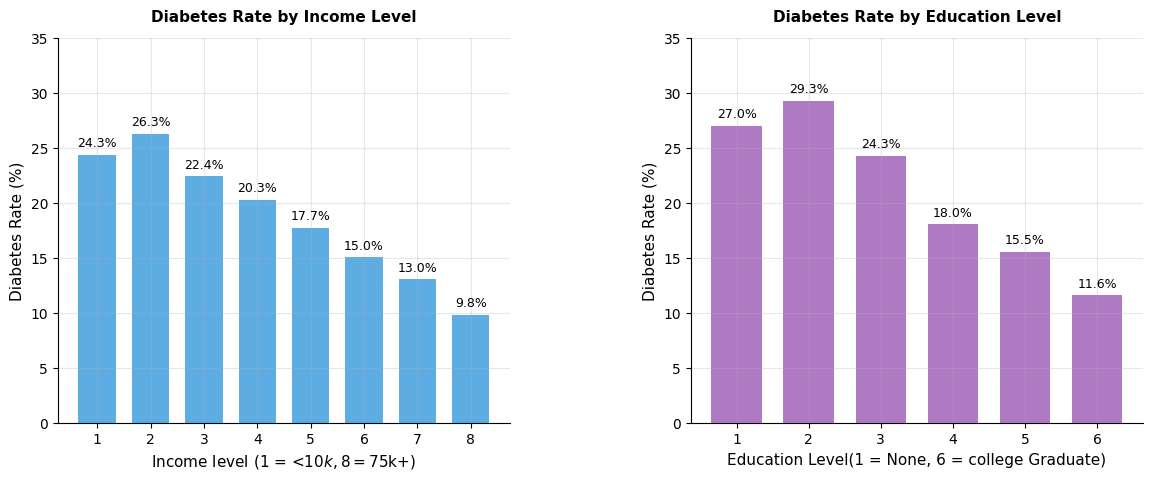

HEALTHCARE ACCESS FINDINGS

Diabetes rate - Lowest income (1): 24.3%
Diabetes rate - Highest income (8): 9.8%

Diabetes rate - No education (1): 27.0%

Diabetes rate - college grad (6): 11.6%


In [9]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))
plt.subplots_adjust(wspace=0.4)

# Income vs Diabetes Rate
income_rate = df.groupby('Income')['Diabetes_binary'].mean().sort_index() * 100

axes[0].bar(
    income_rate.index,
    income_rate.values,
    color='#3498db',
    alpha=0.8,
    width=0.7
)

axes[0].set_title(
    'Diabetes Rate by Income Level',
    fontsize=11,
    fontweight='bold',
    pad=12
)

axes[0].set_xlabel('Income level (1 = <$10k, 8 = $75k+)')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].set_ylim(0, 35)

for i, val in zip(income_rate.index, income_rate.values):
    axes[0].text(
        i,
        val + 0.5,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Education vs Diabetes Rate
edu_rate = df.groupby('Education')['Diabetes_binary'].mean().sort_index() * 100

axes[1].bar(
    edu_rate.index,
    edu_rate.values,
    color='#9b59b6',
    alpha=0.8,
    width=0.7
)

axes[1].set_title(
    'Diabetes Rate by Education Level',
    fontsize=11,
    fontweight='bold',
    pad=12
)

axes[1].set_xlabel('Education Level(1 = None, 6 = college Graduate)')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].set_ylim (0, 35)

for i, val in zip(edu_rate.index, edu_rate.values):
    axes[1].text(
        i,
        val + 0.5,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.savefig('../visuals/heatlhcare_access.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key stats
print("=" * 45)
print("HEALTHCARE ACCESS FINDINGS")
print("=" * 45)
print(f"\nDiabetes rate - Lowest income (1): {income_rate[1]:.1f}%")
print(f"Diabetes rate - Highest income (8): {income_rate[8]:.1f}%")
print(f"\nDiabetes rate - No education (1): {edu_rate[1]:.1f}%")
print(f"\nDiabetes rate - college grad (6): {edu_rate[6]:.1f}%")



### Healthcare Access Findings

**Income:**
- Diabetes rates generally decline as income level increases.
- Respondents in the lowest income category had a diabetes rate of **24.3%**, compared with **9.8%** among respondents in the highest income category.
- This represents a difference of **14.5 percentage points**, suggesting a strong relationship between lower income and higher diabetes risk in the dataset.
- From a data science perspective, `Income` appears to be an important socioeconomic predictor for the final model.

**Education:**
- Diabetes rates are higher among respondents with lower education levels and generally decline as education level increases.
- Respondents in education level 1 had a diabetes rate of **27.0%**, while college graduates had a diabetes rate of **11.6%**.
- The highest diabetes rate appears in education level 2 at **29.3%**, suggesting that very low educational attainment is associated with higher diabetes burden.
- This trend supports the importance of education as a social determinant of health and a useful feature for risk prediction.

**Overall Insight:**
- Both income and education show clear socioeconomic gradients in diabetes rates.
- Lower income and lower education levels are associated with higher diabetes rates in this dataset.
- These variables should be retained in the modeling pipeline because they provide useful context beyond clinical and lifestyle factors.

## 9. Correlation Analysis

In this section, we calculate the Pearson correlation between each feature and the target variable, `Diabetes_binary`.

This helps identify which variables have the strongest positive or negative linear association with diabetes status. Positive correlations indicate that higher values of a feature are associated with higher diabetes risk, while negative correlations suggest that higher values are associated with lower diabetes risk.

Because many variables in this dataset are binary or ordinal, correlation should be interpreted as an exploratory signal rather than proof of causation.

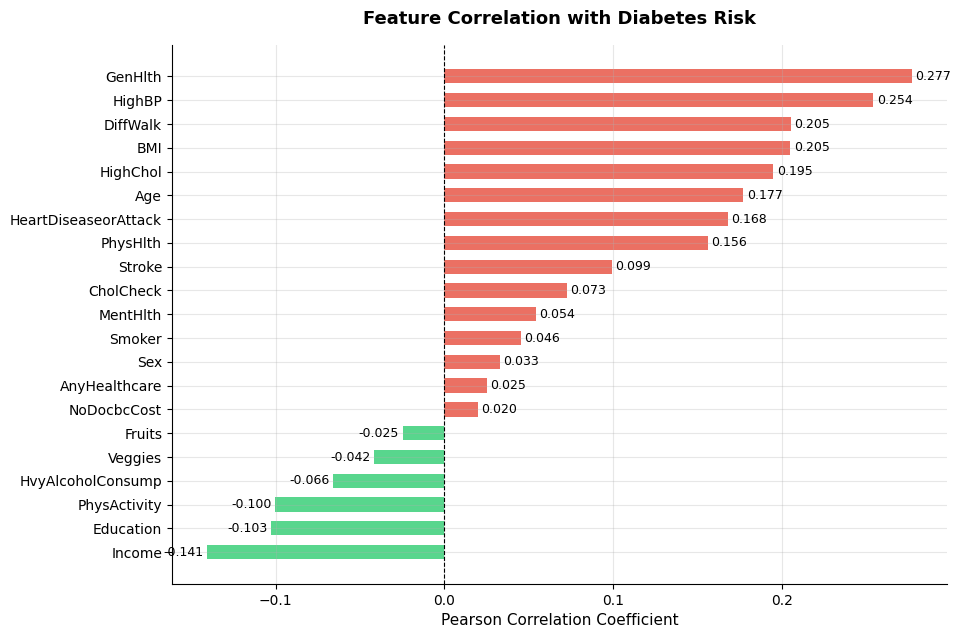


Top 5 positive correlations:
GenHlth     0.276940
HighBP      0.254318
DiffWalk    0.205302
BMI         0.205086
HighChol    0.194944
Name: Diabetes_binary, dtype: float64

Top 5 negative correlations:
Income              -0.140659
Education           -0.102686
PhysActivity        -0.100404
HvyAlcoholConsump   -0.065950
Veggies             -0.041734
Name: Diabetes_binary, dtype: float64


In [11]:
# Correlation with diabetes target-sorted bar chart
fig, ax = plt.subplots(figsize=(10, 7))

corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary')
corr_sorted = corr.sort_values(ascending=True)

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_sorted]

ax.barh(corr_sorted.index,
        corr_sorted.values,
       color=colors,
       alpha=0.8,
       height=0.6)

ax.axvline(x=0,
          color='black',
          linewidth=0.8,
          linestyle='--'
)

ax.set_title('Feature Correlation with Diabetes Risk',
            fontsize=13,
            fontweight='bold',
            pad=15
)

ax.set_xlabel('Pearson Correlation Coefficient')

for i, (val, name) in enumerate(zip(corr_sorted.values,
                               corr_sorted.index)):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        i, 
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right', 
        fontsize=9
    )

plt.savefig('../visuals/correction_bar_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 positive correlations:")
print(corr.sort_values(ascending=False).head(5))
print("\nTop 5 negative correlations:")
print(corr.sort_values(ascending=True).head(5))

### Correlation Analysis Findings

**Top Positive Correlations:**
- `GenHlth` has the strongest positive correlation with diabetes (**0.277**), meaning respondents reporting poorer general health are more likely to be diabetic.
- `HighBP` is the second strongest positive predictor (**0.254**), showing that high blood pressure is strongly associated with diabetes status.
- `DiffWalk` (**0.205**) and `BMI` (**0.205**) also show meaningful positive relationships with diabetes, suggesting that mobility difficulty and higher body mass index are important risk indicators.
- `HighChol` has a positive correlation of **0.195**, confirming that high cholesterol is also associated with diabetes risk.

**Top Negative Correlations:**
- `Income` has the strongest negative correlation with diabetes (**-0.141**), indicating that higher income levels are associated with lower diabetes rates.
- `Education` also shows a negative correlation (**-0.103**), suggesting that higher education levels are linked with lower diabetes risk.
- `PhysActivity` has a negative correlation (**-0.100**), supporting earlier findings that physically active respondents tend to have lower diabetes rates.
- `HvyAlcoholConsump` shows a negative correlation (**-0.066**), but this should be interpreted carefully because it may reflect confounding factors rather than a protective effect.
- `Veggies` has a small negative correlation (**-0.042**), suggesting a weak association between daily vegetable consumption and lower diabetes rates.

**Overall Insight:**
- The strongest diabetes-related features are a mix of clinical, physical health, and socioeconomic variables.
- Poor general health, high blood pressure, difficulty walking, higher BMI, and high cholesterol are positively associated with diabetes.
- Higher income, higher education, physical activity, and healthier dietary habits are negatively associated with diabetes.
- These results support retaining both medical and socioeconomic features in the prediction model.
- Since correlation only measures association, these findings should guide feature selection but should not be interpreted as proof of causation.

---
## ✅ Exploratory Analysis Complete

**Dataset:** 229,474 records · 22 columns · 0 missing values  
**Class balance:** 84.7% No Diabetes · 15.3% Diabetes  

### Key Findings That Inform the Model

| Finding | Modelling Implication |
|---|---|
| 85/15 class imbalance | Use stratified train-test split and handle imbalance during training |
| `GenHlth` is the strongest correlated feature | Expected to rank highly in feature importance |
| `HighBP`, `BMI`, `DiffWalk`, and `HighChol` show strong positive associations | Retain as primary clinical and health-status features |
| `Income` and `Education` show strong negative correlations | Socioeconomic features add useful predictive signal |
| Physical inactivity is associated with a higher diabetes rate | `PhysActivity` should be retained as a key lifestyle feature |
| All features are already numeric | No categorical encoding is required in Notebook 2 |

> **Next:** Open `02_feature_engineering.ipynb` to prepare the final feature set for model training.